<h1>🌠 AI-Based Stellar Prediction System</h1>

<h1 style="font-size:30px;">🎯 Project Objective</h1>

The objective of this project is to develop a machine learning classification model capable of accurately predicting the type or class of a star based on its physical and observational characteristics.

<h1 style="font-size:30px;">📚 Import Libraries</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV


import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve


<h1 style="font-size:30px;">📂 Dataset Loading</h1>

In [2]:
df=pd.read_csv("star_classification.csv")
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


<h1 style="font-size:30px;">🔍 Exploratory Data Analysis (EDA)</h1>

<h1 style="font-size:25px;">1.Basic dataset information</h1>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.shape

(100000, 18)

In [5]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [7]:
df.drop("rerun_ID",axis=1,inplace=True)

<h1 style="font-size:25px;">2. Missing value analysis</h1>

In [8]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<h1 style="font-size:25px;">3. 📊Data Visualization</h1>

1. Distribution of Target Classes

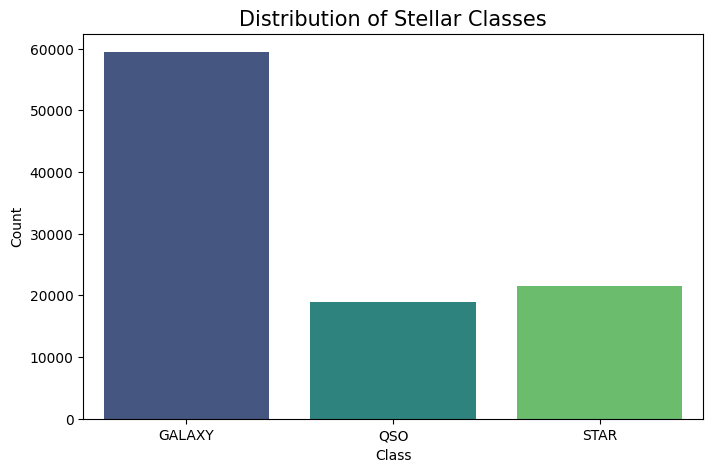

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x='class', data=df, palette='viridis')

plt.title("Distribution of Stellar Classes", fontsize=15)
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

2. Percentage Distribution

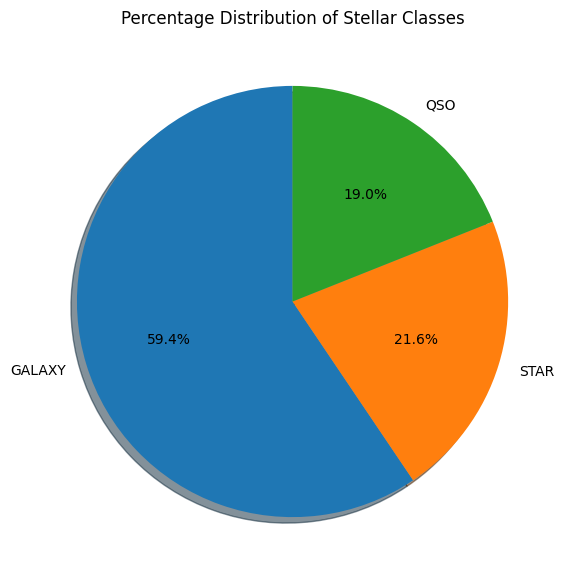

In [11]:
plt.figure(figsize=(7,7))

df['class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Percentage Distribution of Stellar Classes")
plt.ylabel("")

plt.show()

3.Distribution of Redshift

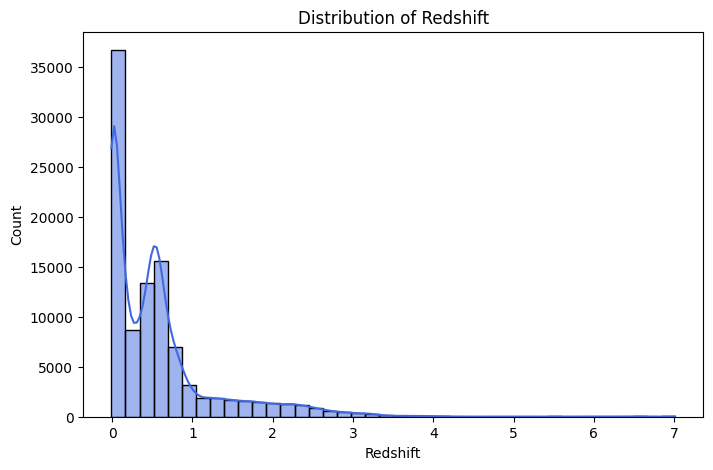

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['redshift'],
    bins=40,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Redshift")
plt.xlabel("Redshift")

plt.show()

4. Scatter Plot (u vs g)

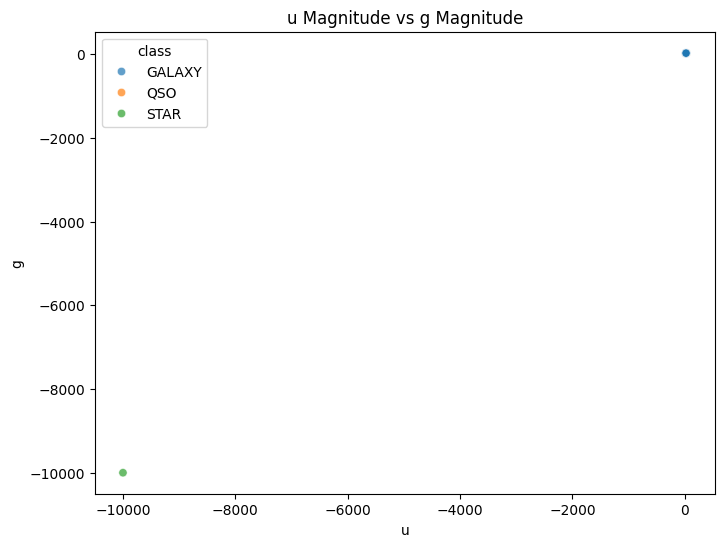

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='u',
    y='g',
    hue='class',
    alpha=0.7
)

plt.title("u Magnitude vs g Magnitude")

plt.show()

5.Pair Plot

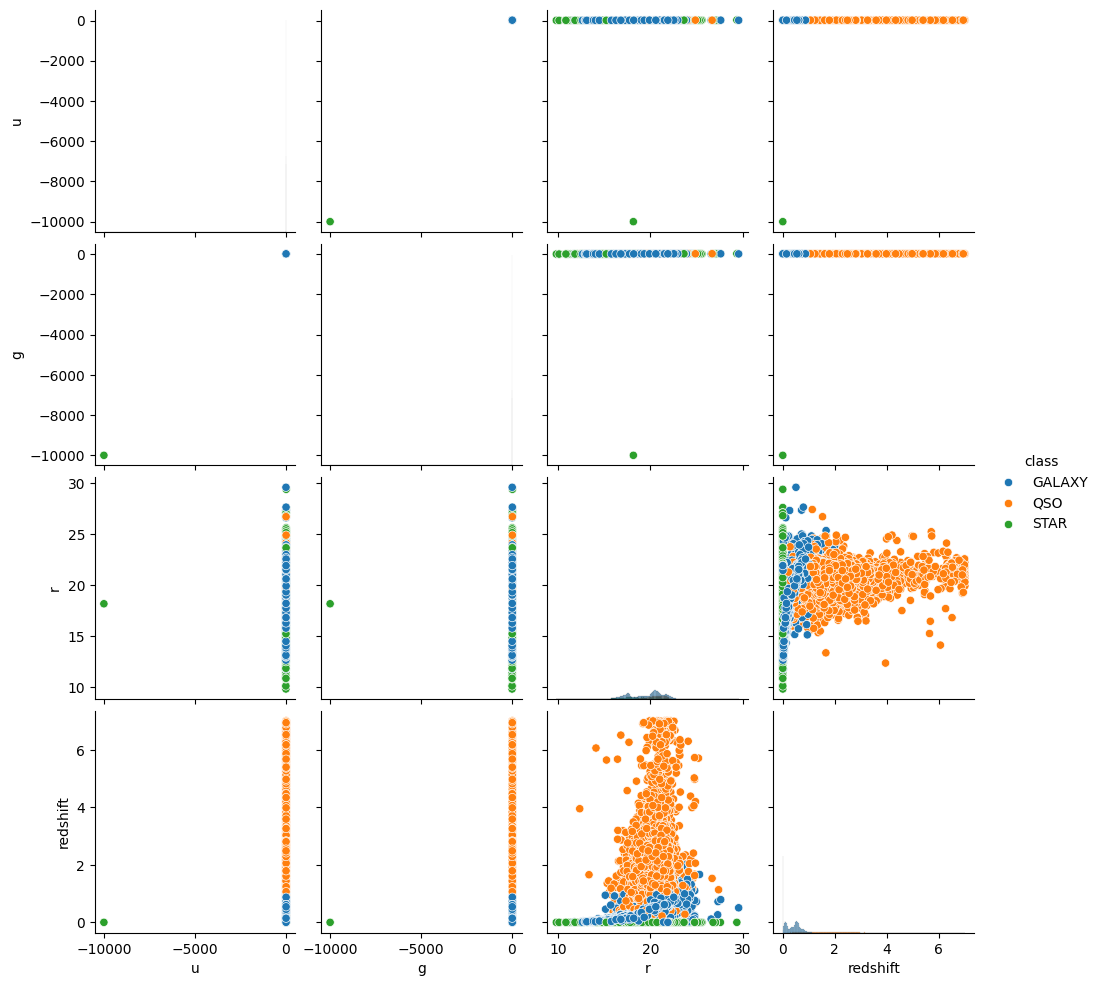

In [14]:
selected = df[['u','g','r','redshift','class']]

sns.pairplot(
    selected,
    hue='class',
    diag_kind='hist'
)

plt.show()

6. Boxplots

<Axes: >

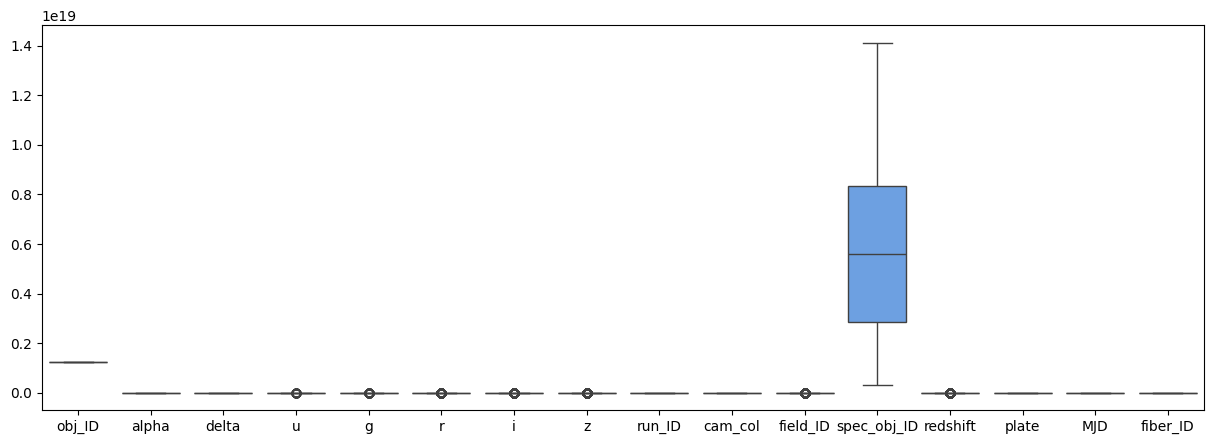

In [15]:
plt.figure(figsize=(15,5))
sns.boxplot(df)

7.Scatter Plot (Redshift vs z)

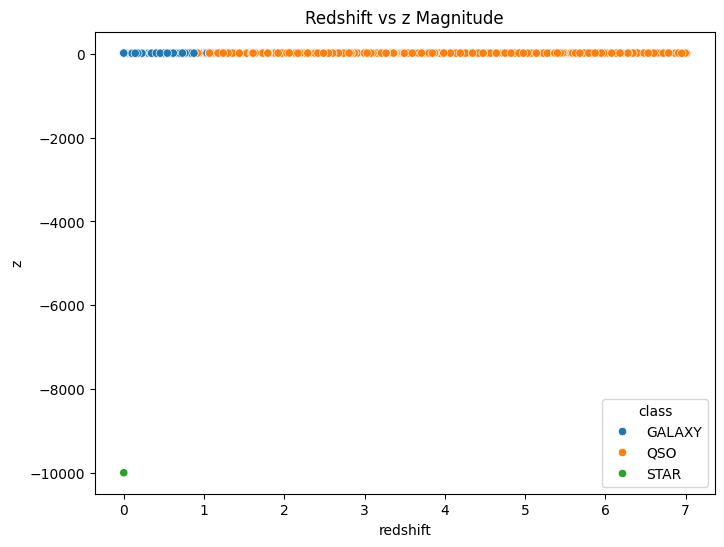

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='redshift',
    y='z',
    hue='class'
)

plt.title("Redshift vs z Magnitude")

plt.show()

CONCLUSION

-->The visualizations show that the dataset is complete and suitable for machine learning analysis.

-->The three classes (STAR, GALAXY, and QSO) exhibit different patterns across the features.

-->Redshift and the photometric magnitude features (u, g, r, i, and z) show clear differences among the classes, making them important for classification.

<h1 style="font-size:25px;">4.Outlier Removal</h1>

In [17]:
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy='mean')
df[["u","g","r","i","z"]]=impute.fit_transform(df[["u","g","r","i","z"]])

<h1 style="font-size:25px;">5. Feature Selection</h1>

In [18]:
corr = df.corr(numeric_only=True)

print(corr)

               obj_ID     alpha     delta         u         g         r  \
obj_ID       1.000000 -0.013735 -0.301237  0.015310  0.015710  0.153891   
alpha       -0.013735  1.000000  0.138691 -0.001532 -0.002423 -0.022083   
delta       -0.301237  0.138691  1.000000  0.002074  0.003523 -0.006835   
u            0.015310 -0.001532  0.002074  1.000000  0.999311  0.054149   
g            0.015710 -0.002423  0.003523  0.999311  1.000000  0.062387   
r            0.153891 -0.022083 -0.006835  0.054149  0.062387  1.000000   
i            0.147670 -0.023580 -0.004480  0.045730  0.056271  0.962868   
z            0.013811 -0.002918  0.003630  0.998093  0.999161  0.053677   
run_ID       1.000000 -0.013737 -0.301238  0.015309  0.015710  0.153889   
cam_col     -0.046997  0.019582  0.032565  0.003548  0.003508  0.008480   
field_ID     0.031498 -0.165577 -0.173416 -0.008374 -0.008852 -0.026423   
spec_obj_ID  0.239461 -0.002553  0.112329  0.029997  0.039443  0.655245   
redshift     0.065400  0.

<h1 style="font-size:25px;">5.Encoding</h1>

In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['class'] = label_encoder.fit_transform(df['class'])

print(label_encoder.classes_)

['GALAXY' 'QSO' 'STAR']


<h1 style="font-size:25px;">6. Feature Selection</h1>

In [20]:

x = df.drop([
    'class',
    'obj_ID',
    'run_ID',
    'field_ID',
    'spec_obj_ID'
], axis=1)

# Target
y = df['class']


In [21]:
x

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,0.634794,5812,56354,171
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,0.779136,10445,58158,427
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,0.644195,4576,55592,299
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,0.932346,9149,58039,775
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,2,0.000000,9374,57749,438
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,1,0.404895,7626,56934,866
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,4,0.143366,2764,54535,74
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,4,0.455040,6751,56368,470


In [22]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: class, Length: 100000, dtype: int64

<h1 style="font-size:25px;">7.Data Balancing</h1>

In [23]:

import matplotlib.pyplot as plt

# Count samples in each class
class_counts = df['class'].value_counts()

print("Class Distribution:")
print(class_counts)

# Percentage distribution
class_percentage = df['class'].value_counts(normalize=True) * 100

print("\nClass Percentage:")
print(class_percentage.round(2))

# Calculate imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nImbalance Ratio : {imbalance_ratio:.2f}")

# Determine balance status
if imbalance_ratio <= 1.5:
    print("\nDataset Status : Balanced")
elif imbalance_ratio <= 3:
    print("\nDataset Status : Slightly Imbalanced")
else:
    print("\nDataset Status : Moderately Imbalanced (Sampling can be considered)")

Class Distribution:
class
0    59445
2    21594
1    18961
Name: count, dtype: int64

Class Percentage:
class
0    59.44
2    21.59
1    18.96
Name: proportion, dtype: float64

Imbalance Ratio : 3.14

Dataset Status : Moderately Imbalanced (Sampling can be considered)


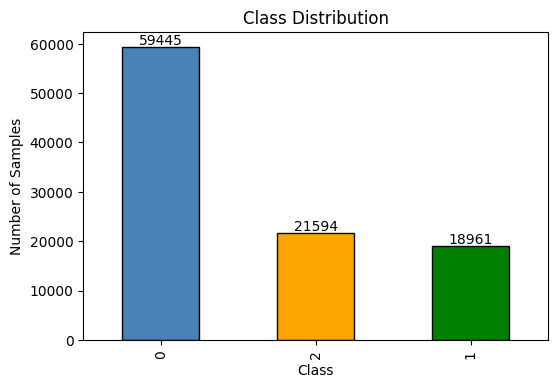

In [24]:
plt.figure(figsize=(6,4))

class_counts.plot(kind='bar',
                  color=['steelblue','orange','green'],
                  edgecolor='black')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for i, v in enumerate(class_counts):
    plt.text(i, v + 500, str(v), ha='center', fontsize=10)

plt.show()

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    x,
    y
)

print("After SMOTE")
print(y_train_smote.value_counts())

After SMOTE
class
0    59445
1    59445
2    59445
Name: count, dtype: int64


<h1 style="font-size:25px;">8. Train-Test Split</h1>

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [27]:
print(x_train.shape)
print(x_test.shape)

(70000, 12)
(30000, 12)


In [28]:
print(y_train.shape)
print(y_test.shape)

(70000,)
(30000,)


In [29]:
print(x_test.dtypes)
print(x_train.dtypes)

alpha       float64
delta       float64
u           float64
g           float64
r           float64
i           float64
z           float64
cam_col       int64
redshift    float64
plate         int64
MJD           int64
fiber_ID      int64
dtype: object
alpha       float64
delta       float64
u           float64
g           float64
r           float64
i           float64
z           float64
cam_col       int64
redshift    float64
plate         int64
MJD           int64
fiber_ID      int64
dtype: object


<h1 style="font-size:25px;">9. Scaling</h1>

In [30]:
scale=StandardScaler()
xs_train=scale.fit_transform(x_train)
xs_test=scale.transform(x_test)

<h1 style="font-size:40px;">🤖 Model Building </h1>

In [31]:
models={"LogisticRegression":LogisticRegression(max_iter=1000),
        
        "DecisionTreeClassifier":DecisionTreeClassifier(random_state=42),

        "RandomForestClassifier":RandomForestClassifier(random_state=42),

        "KNeighborsClassifier":KNeighborsClassifier(),

        "SVC":SVC(),

        "GaussianNB":GaussianNB(),

        "XGBClassifier":XGBClassifier(random_state=42,
            eval_metric='mlogloss'),

        "GradientBoostingClassifier":GradientBoostingClassifier(),

        "AdaBoostClassifier":AdaBoostClassifier(),
        
        "BaggingClassifier":BaggingClassifier()}

<h1 style="font-size:25;">Model Evaluation</h1>

In [32]:
M = []

for name, model in models.items():

    model.fit(xs_train, y_train)

    pred = model.predict(xs_test)

    acc = accuracy_score(y_test, pred)

    prec = precision_score(y_test, pred, average="weighted")

    rec = recall_score(y_test, pred, average="weighted")

    f1 = f1_score(y_test, pred, average="weighted")

    M.append([name, acc, prec, rec, f1])

<h1 style="font-size:25;">Model Comparison</h1>

In [33]:
results_df = pd.DataFrame(
    M,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,RandomForestClassifier,0.979033,0.978932,0.979033,0.978896
1,BaggingClassifier,0.977167,0.977053,0.977167,0.977003
2,XGBClassifier,0.977100,0.977000,0.977100,0.976994
3,GradientBoostingClassifier,0.976067,0.975971,0.976067,0.975854
4,DecisionTreeClassifier,0.964200,0.964247,0.964200,0.964223
5,SVC,0.962833,0.963096,0.962833,0.962671
6,LogisticRegression,0.957133,0.957084,0.957133,0.956748
7,KNeighborsClassifier,0.921333,0.921859,0.921333,0.920619
8,GaussianNB,0.898033,0.911007,0.898033,0.901359
9,AdaBoostClassifier,0.887367,0.899404,0.887367,0.890645


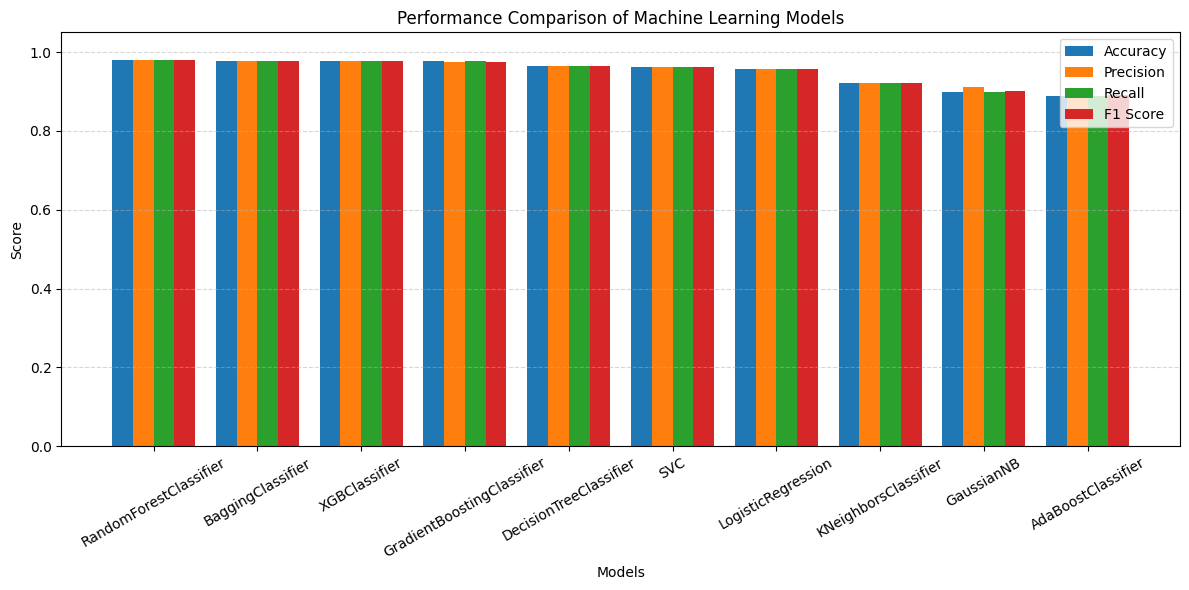

In [34]:

x = np.arange(len(results_df["Model"]))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x-0.3, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x-0.1, results_df["Precision"], width, label="Precision")
plt.bar(x+0.1, results_df["Recall"], width, label="Recall")
plt.bar(x+0.3, results_df["F1 Score"], width, label="F1 Score")

plt.xticks(x, results_df["Model"], rotation=30)
plt.ylabel("Score")
plt.xlabel("Models")
plt.title("Performance Comparison of Machine Learning Models")
plt.ylim(0, 1.05)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [35]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(xs_train, y_train)

y_pred = best_model.predict(xs_test)

<h1 style="font-size:25;">Model Evaluation</h1>

In [36]:
print(classification_report( y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     17845
           1       0.97      0.93      0.95      5700
           2       0.99      1.00      1.00      6455

    accuracy                           0.98     30000
   macro avg       0.98      0.97      0.98     30000
weighted avg       0.98      0.98      0.98     30000



<h1 style="font-size:25;">ROC-AUC Curve</h1>

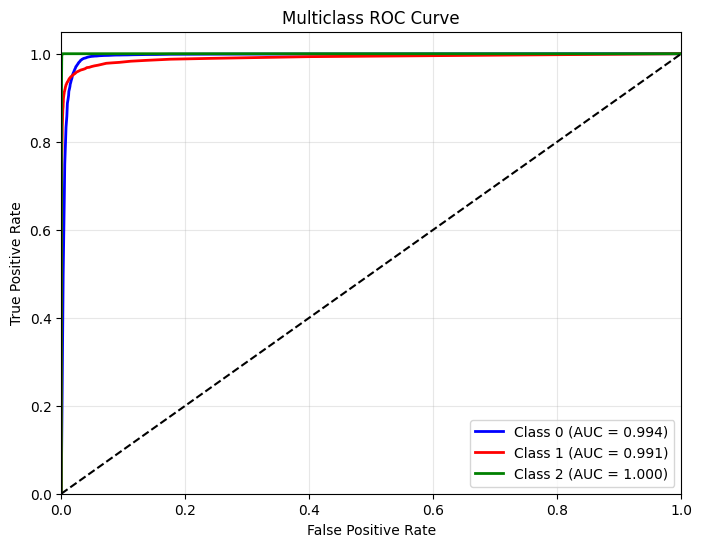

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model.predict_proba(xs_test)

plt.figure(figsize=(8,6))

colors = ['blue', 'red', 'green']

for i, color in zip(range(len(classes)), colors):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f'Class {i} (AUC = {roc_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [38]:

classes = np.unique(y)

roc_auc = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC Score:", round(roc_auc,4))

Weighted ROC-AUC Score: 0.9947


<h1 style="font-size:25;">Cross validation</h1>

In [39]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    best_model,
    xs_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.97735714 0.97857143 0.98071429 0.97764286 0.97728571]
Average CV Score: 0.9783142857142856


<h1 style="font-size:25;">Confusion Matrix </h1>

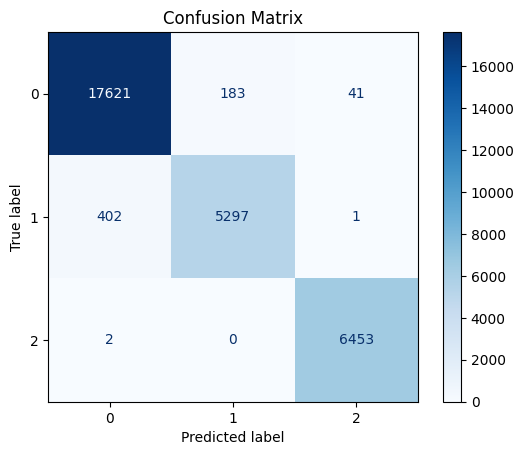

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

<h1 style="font-size:25;">Model Saving</h1>

In [41]:
import pickle

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

# Save the trained model
with open("stellar_classification_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save the scaler
with open("stellar_scaler.pkl", "wb") as file:
    pickle.dump(scale, file)


In [42]:

# Save evaluation metrics + class list for the Streamlit dashboard (app.py)
import pickle
from sklearn.metrics import confusion_matrix

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="weighted"),
    "recall": recall_score(y_test, y_pred, average="weighted"),
    "f1": f1_score(y_test, y_pred, average="weighted"),
    "roc_auc": roc_auc,
    "cv_mean": cv_scores.mean(),
    "n_train": len(x_train),
    "n_test": len(x_test),
    "n_total": len(x),
    "best_model": "RandomForestClassifier",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "comparison": results_df,
    "classes": list(label_encoder.classes_),
}

with open("model_metrics.pkl", "wb") as file:
    pickle.dump(metrics, file)

print("Saved model_metrics.pkl")


Saved model_metrics.pkl


<h1 style="font-size:25;">CONCLUSION</h1>

Multiple machine learning classification models were developed and compared for stellar object classification. The Random Forest Classifier achieved the best performance based on evaluation metrics such as accuracy, precision, recall, and F1-score, demonstrating excellent classification capability. The project successfully classified celestial objects into Stars, Galaxies, and Quasars using astronomical features after data preprocessing and exploratory data analysis. The final model was deployed using Streamlit to provide an interactive platform for stellar object classification and prediction.